# EEG dataset exploration

A quick look at the available labels and recordings, followed by the main steps in the covariance-based classification pipeline. To keep the examples fast, the walkthrough uses ten balanced subjects and one minute from each recording state.

In [16]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyriemann.classification import MDM
from pyriemann.tangentspace import TangentSpace
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from pcp_project.classify import FeatureConsolidator, make_subject_folds
from pcp_project.data import (
    DEFAULT_SFREQ,
    LABEL_COLUMNS,
    balanced_subject_ids,
    binary_target,
    list_subject_ids,
    load_labels,
    load_subject,
)
from pcp_project.estimators import (
    BandPassFilter,
    BatchCovariances,
    SlidingWindow,
    StateSelector,
)
from pcp_project.plotting import (
    plot_covariance_ellipses,
    plot_covariance_heatmaps,
    plot_covariance_space,
    plot_mdm_distances,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 7
N_SUBJECTS = 10
SECONDS_PER_STATE = 60
WINDOW_SECONDS = 2
STATE_ORDER = (0, 1)
STATE_NAMES = {0: "Eyes open", 1: "Eyes closed"}
STATE_COLORS = {0: "#4C78A8", 1: "#D99B2B"}
CHANNEL_PAIR = (0, 1)
HEATMAP_CHANNELS = np.arange(8)

samples_per_state = int(SECONDS_PER_STATE * DEFAULT_SFREQ)
window_length = int(WINDOW_SECONDS * DEFAULT_SFREQ)

project_root = Path.cwd()
if not (project_root / "pcp_project").is_dir():
    project_root = project_root.parent

data_dir = Path(
    os.environ.get("PCP_DATA_DIR", project_root / "data" / "data-20260528")
)
labels_path = data_dir / "labels_reduced.csv"
if not labels_path.exists():
    raise FileNotFoundError(
        f"Could not find the project data in {data_dir}. "
        "Set PCP_DATA_DIR to the directory containing the .npz files and labels."
    )

## 1. Dataset coverage and labels

First, check how many subjects have both EEG and SCID-5-CV labels, then look at the label distribution.

In [17]:
labels = load_labels(labels_path)
recording_ids = list_subject_ids(data_dir)
matched_ids = sorted(set(labels.index) & set(recording_ids))

coverage = pd.Series(
    {
        "Labeled subjects": len(labels),
        "EEG recordings": len(recording_ids),
        "Matched EEG + labels": len(matched_ids),
        "Labels without EEG": len(labels) - len(matched_ids),
        "EEG without labels": len(recording_ids) - len(matched_ids),
        "Diagnostic columns": len(LABEL_COLUMNS),
    },
    name="count",
).to_frame()

display(coverage)

,count
Labeled subjects,146
EEG recordings,44
Matched EEG + labels,44
Labels without EEG,102
EEG without labels,0
Diagnostic columns,17


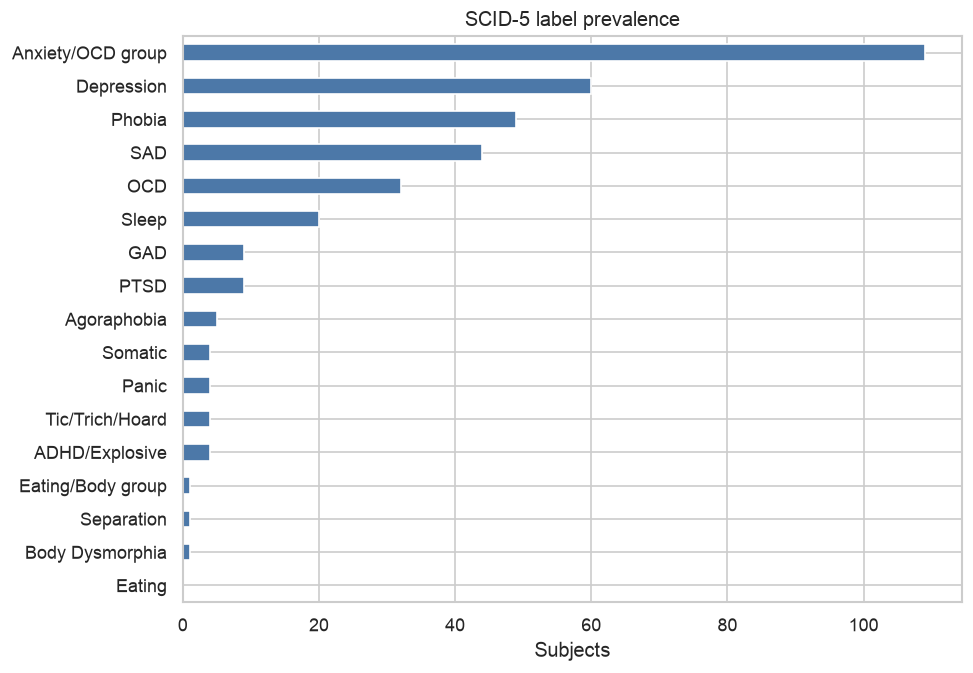

In [18]:
SHORT_NAMES = {
    "SCID5_CV_Depression": "Depression",
    "SCID5_CV_OCD": "OCD",
    "SCID5_CV_Tic_TrichoDerma_Hoarding": "Tic/Trich/Hoard",
    "SCID5_CV_SAD": "SAD",
    "SCID5_CV_PHOB": "Phobia",
    "SCID5_CV_PANIC": "Panic",
    "SCID5_CV_AGORA": "Agoraphobia",
    "SCID5_CV_GAD": "GAD",
    "SCID5_CV_PTSD": "PTSD",
    "SCID5_CV_Soma_Health": "Somatic",
    "SCID5_CV_Separation": "Separation",
    "SCID5_CV_Sleep": "Sleep",
    "SCID5_CV_Bodydysmorphia": "Body Dysmorphia",
    "SCID5_CV_Eating": "Eating",
    "SCID5_CV_Anxiety_OCD_etc": "Anxiety/OCD group",
    "SCID5_CV_Eating_Bodydysmorphia": "Eating/Body group",
    "SCID5_CV_ADHD_Explosive": "ADHD/Explosive",
}

prevalence = (
    labels.loc[:, LABEL_COLUMNS]
    .sum()
    .rename(index=SHORT_NAMES)
    .sort_values()
)

figure, axis = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
prevalence.plot.barh(ax=axis, color="#4C78A8")
axis.set(
    title="SCID-5 label prevalence",
    xlabel="Subjects",
    ylabel="",
)
figure;

Only the 44 subjects with both EEG and labels are used below. Subjects may have zero, one, or several positive labels.

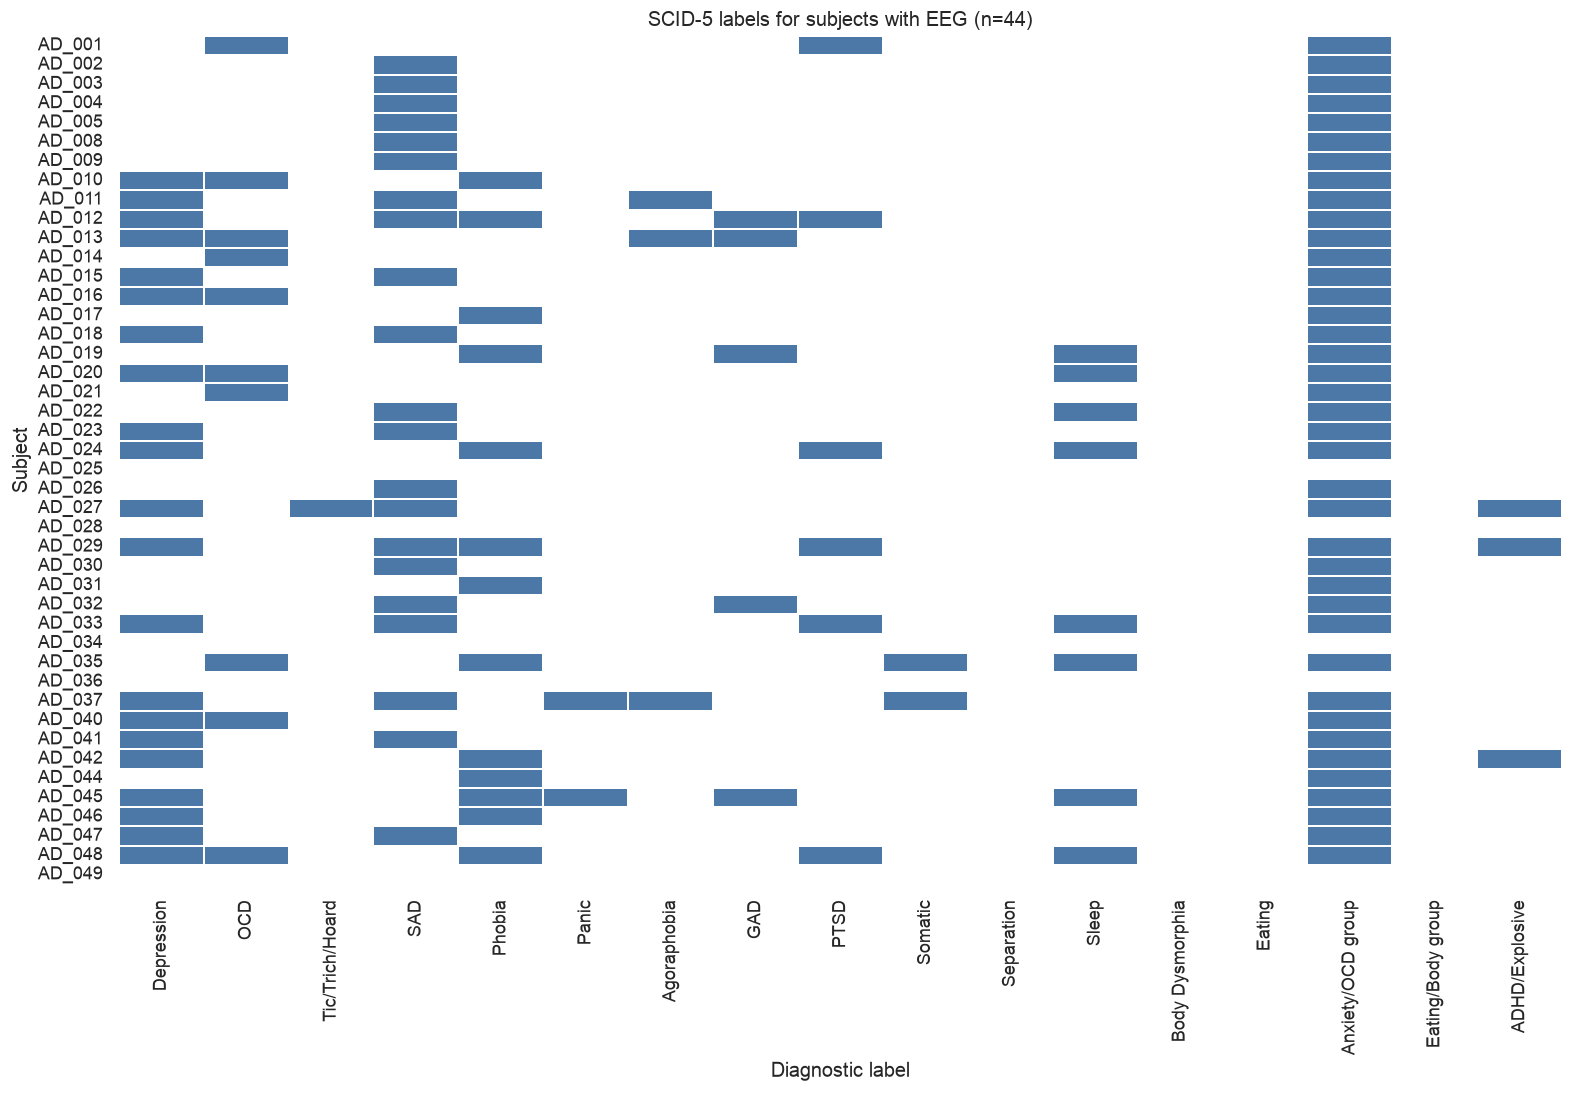

In [19]:
label_heatmap = labels.loc[matched_ids, LABEL_COLUMNS].rename(columns=SHORT_NAMES)

figure, axis = plt.subplots(figsize=(13, 9), constrained_layout=True)
sns.heatmap(
    label_heatmap,
    cmap=sns.color_palette(["#ffffff", "#4C78A8"], as_cmap=True),
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.2,
    linecolor="white",
    ax=axis,
)
axis.set(
    title=f"SCID-5 labels for subjects with EEG (n={len(matched_ids)})",
    xlabel="Diagnostic label",
    ylabel="Subject",
)
figure;

The labels overlap considerably. For the small classification example, they are reduced to an any-diagnosis target.

## 2. One EEG recording

Each file contains a channels × samples array at 256 Hz and a sample-level eyes-open/eyes-closed state vector. Electrode names are not available, so plots use channel numbers.

In [20]:
records = []
for subject_id in matched_ids:
    path = data_dir / f"{subject_id}.npz"
    with np.load(path) as npz:
        n_samples, n_channels = npz["X"].shape
        state_values = np.unique(npz["y"])
    records.append(
        {
            "subject": subject_id,
            "n_samples": n_samples,
            "n_channels": n_channels,
            "duration_min": n_samples / DEFAULT_SFREQ / 60,
            "n_states": len(state_values),
        }
    )

eeg_summary = pd.DataFrame(records).set_index("subject")
sample_id = matched_ids[0]
sample_recording, sample_states = load_subject(sample_id, data_dir)

changes = np.flatnonzero(np.diff(sample_states) != 0) + 1
starts = np.r_[0, changes]
stops = np.r_[changes, len(sample_states)]
segments = pd.DataFrame(
    {
        "state": sample_states[starts].astype(int),
        "duration_min": (stops - starts) / DEFAULT_SFREQ / 60,
    }
)

print(f"Sample: {sample_id}")
print(f"Recording shape: {sample_recording.shape} (channels × samples)")
print(f"States: {dict(zip(*np.unique(sample_states, return_counts=True)))}")
display(
    eeg_summary[["n_channels", "duration_min", "n_states"]].agg(
        ["min", "median", "max"]
    )
)
display(segments)

Sample: AD_001
Recording shape: (61, 490916) (channels × samples)
States: {np.int64(0): np.int64(245609), np.int64(1): np.int64(245307)}


,n_channels,duration_min,n_states
min,61.0,31.959701,2.0
median,61.0,31.960482,2.0
max,61.0,31.970964,2.0


,state,duration_min
0,0,3.997786
1,1,7.985482
2,0,3.997526
3,1,3.992578
4,0,7.994857
5,1,3.992448


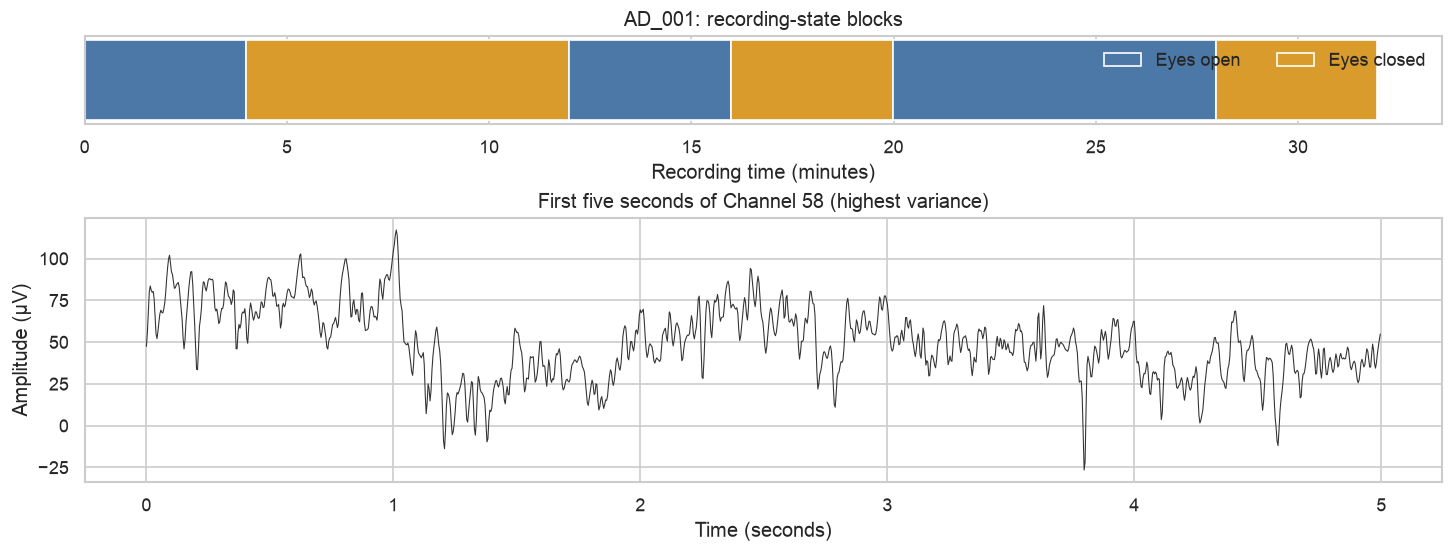

In [21]:
channel_variances = sample_recording.var(axis=1)
example_channel = int(np.argmax(channel_variances))
n_waveform_samples = int(5 * DEFAULT_SFREQ)
waveform_time = np.arange(n_waveform_samples) / DEFAULT_SFREQ
waveform_microvolts = sample_recording[example_channel, :n_waveform_samples] * 1e6

figure, (timeline_axis, waveform_axis) = plt.subplots(
    2,
    1,
    figsize=(12, 4.5),
    gridspec_kw={"height_ratios": (1, 3)},
    constrained_layout=True,
)
left = 0.0
seen_states = set()
for row in segments.itertuples(index=False):
    label = STATE_NAMES[row.state] if row.state not in seen_states else "_nolegend_"
    timeline_axis.barh(
        0,
        row.duration_min,
        left=left,
        height=0.65,
        color=STATE_COLORS[row.state],
        label=label,
    )
    seen_states.add(row.state)
    left += row.duration_min

timeline_axis.set(
    title=f"{sample_id}: recording-state blocks",
    xlabel="Recording time (minutes)",
    yticks=[],
)
timeline_axis.legend(frameon=False, ncols=2, loc="upper right")

waveform_axis.plot(
    waveform_time,
    waveform_microvolts,
    linewidth=0.65,
    color="#333333",
)
waveform_axis.set(
    title=f"First five seconds of Channel {example_channel + 1} (highest variance)",
    xlabel="Time (seconds)",
    ylabel="Amplitude (µV)",
)
figure;

boundary = changes[0]
boundary_radius = int(6 * DEFAULT_SFREQ)
boundary_slice = slice(boundary - boundary_radius, boundary + boundary_radius)
boundary_signal_microvolts = sample_recording[0, boundary_slice].copy() * 1e6
boundary_states = sample_states[boundary_slice].copy()

del sample_recording, sample_states

## 3. Filtering and windowing

Use five subjects from each target group. Keep one minute per state, filter to 4–15 Hz, and split the signal into two-second windows.

In [22]:
subject_ids = balanced_subject_ids(
    data_dir,
    N_SUBJECTS,
    random_state=RANDOM_STATE,
)
target = binary_target(labels, subject_ids)
state_selector = StateSelector(states=("eyes_open", "eyes_closed"))


def load_short_runs(subject_id):
    recording, states = load_subject(subject_id, data_dir)
    state_runs = state_selector.fit_transform([(recording, states)])[0]
    chosen_runs = []

    for state_code in STATE_ORDER:
        run_recording, run_states = next(
            run for run in state_runs if int(run[1][0]) == state_code
        )
        if run_recording.shape[1] < samples_per_state:
            raise ValueError(
                f"{subject_id} has less than {SECONDS_PER_STATE} seconds of "
                f"{STATE_NAMES[state_code].lower()} data."
            )
        chosen_runs.append(
            (
                run_recording[:, :samples_per_state].copy(),
                run_states[:samples_per_state].copy(),
            )
        )

    return chosen_runs


short_runs = [load_short_runs(subject_id) for subject_id in subject_ids]
cohort = pd.DataFrame(
    {
        "subject": subject_ids,
        "group": np.where(target == 1, "At least one diagnosis", "No diagnosis"),
    }
)
display(cohort)

,subject,group
0,AD_025,No diagnosis
1,AD_026,At least one diagnosis
2,AD_028,No diagnosis
3,AD_030,At least one diagnosis
4,AD_034,No diagnosis
5,AD_036,No diagnosis
6,AD_042,At least one diagnosis
7,AD_044,At least one diagnosis
8,AD_048,At least one diagnosis
9,AD_049,No diagnosis


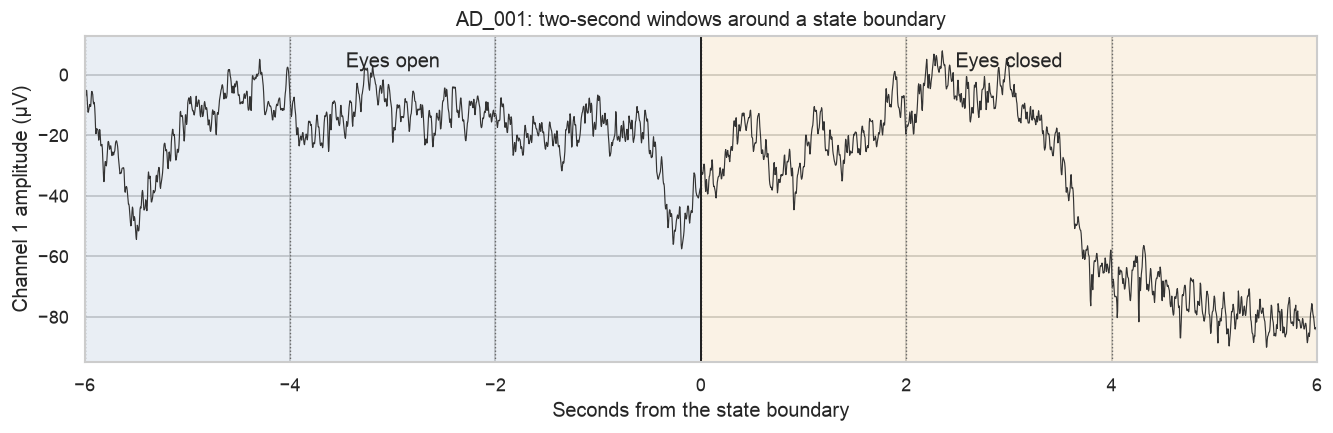

In [23]:
time_from_boundary = (
    np.arange(len(boundary_signal_microvolts)) - boundary_radius
) / DEFAULT_SFREQ
left_state, right_state = int(boundary_states[0]), int(boundary_states[-1])

figure, axis = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
axis.plot(time_from_boundary, boundary_signal_microvolts, color="#333333", linewidth=0.7)

for start, stop, state_code in [(-6, 0, left_state), (0, 6, right_state)]:
    axis.axvspan(start, stop, color=STATE_COLORS[state_code], alpha=0.12)
    axis.text(
        (start + stop) / 2,
        0.95,
        STATE_NAMES[state_code],
        ha="center",
        va="top",
        transform=axis.get_xaxis_transform(),
    )

for edge in np.arange(-6, 6 + WINDOW_SECONDS, WINDOW_SECONDS):
    axis.axvline(edge, color="#666666", linewidth=0.8, linestyle=":")
axis.axvline(0, color="#222222", linewidth=1.2)
axis.set(
    title=f"{sample_id}: two-second windows around a state boundary",
    xlabel="Seconds from the state boundary",
    ylabel="Channel 1 amplitude (µV)",
    xlim=(-6, 6),
)
figure;

In [24]:
filtered_runs = BandPassFilter(
    ((4.0, 15.0),),
    sfreq=DEFAULT_SFREQ,
).fit_transform(short_runs)

windows, window_metadata = SlidingWindow(
    length=window_length,
    step_size=window_length,
    padding_policy="valid",
).fit_transform(filtered_runs)
window_subjects, window_states = window_metadata
window_covariances = BatchCovariances(estimator="oas").fit_transform(windows)

subject_state_covariances, subject_order = FeatureConsolidator(
    strategy="stack",
    state_order=STATE_ORDER,
).fit_transform(window_covariances, groups=window_metadata)

print("Windows:", windows.shape)
print("Window covariances:", window_covariances.shape)
print("Subject/state means:", subject_state_covariances.shape)

del filtered_runs, short_runs

Windows: (600, 61, 512)
Window covariances: (600, 61, 61)
Subject/state means: (10, 2, 61, 61)


Each minute contributes 30 windows, made separately within each state. The windows are repeated observations from a subject, not independent samples.

## 4. Covariance matrices

Each window becomes a 61 × 61 covariance matrix: channel variances on the diagonal and channel-pair covariances off the diagonal.

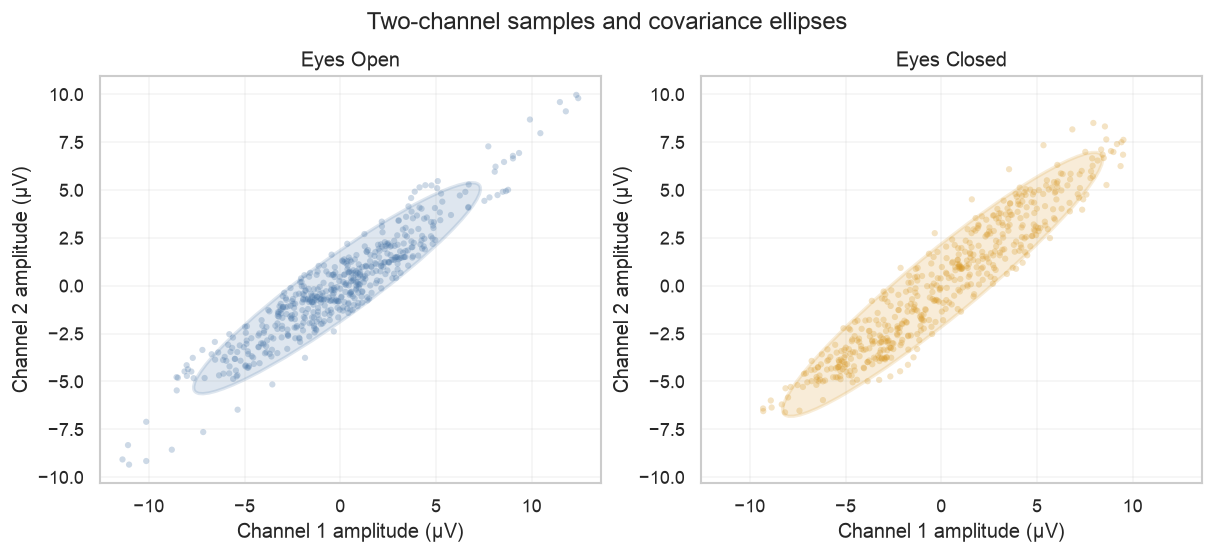

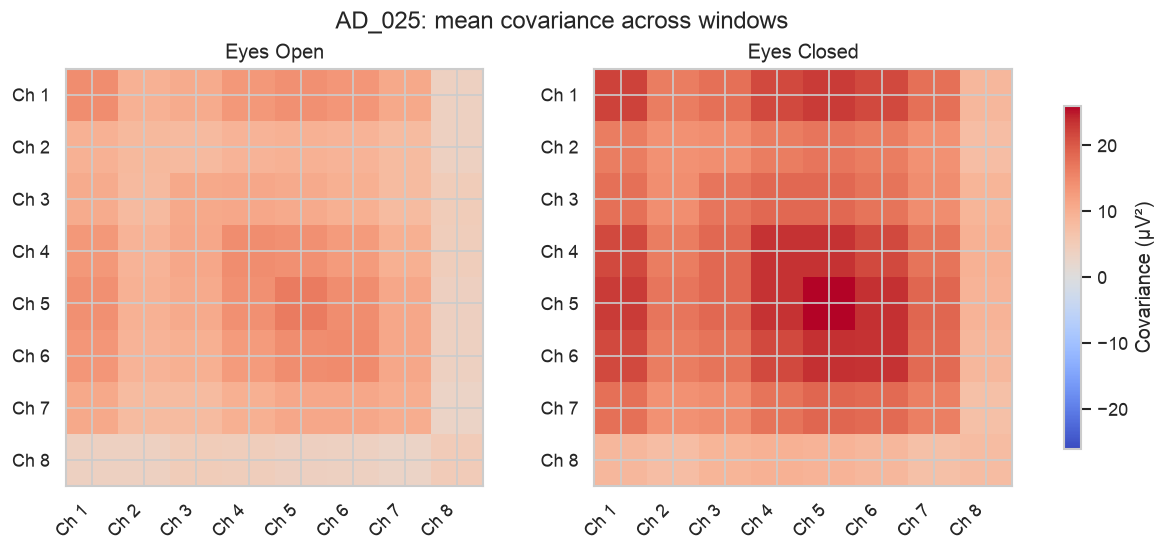

In [25]:
example_windows = {}
for state_code in STATE_ORDER:
    window_index = np.flatnonzero(
        (window_subjects == subject_order[0]) & (window_states == state_code)
    )[0]
    example_windows[STATE_NAMES[state_code]] = (
        windows[window_index, list(CHANNEL_PAIR)] * 1e6
    )

ellipse_figure = plot_covariance_ellipses(
    example_windows,
    channel_names=(
        "Channel 1 amplitude (µV)",
        "Channel 2 amplitude (µV)",
    ),
)
ellipse_figure;

heatmap_channels = list(HEATMAP_CHANNELS)
heatmap_covariances = {
    STATE_NAMES[state_code]: (
        subject_state_covariances[0, state_index][
            np.ix_(heatmap_channels, heatmap_channels)
        ]
        * 1e12
    )
    for state_index, state_code in enumerate(STATE_ORDER)
}
heatmap_figure = plot_covariance_heatmaps(
    heatmap_covariances,
    channel_names=[f"Ch {index + 1}" for index in heatmap_channels],
)
heatmap_figure.axes[-1].set_ylabel("Covariance (µV²)")
heatmap_figure.suptitle(
    f"{subject_ids[subject_order[0]]}: mean covariance across windows"
)
heatmap_figure;

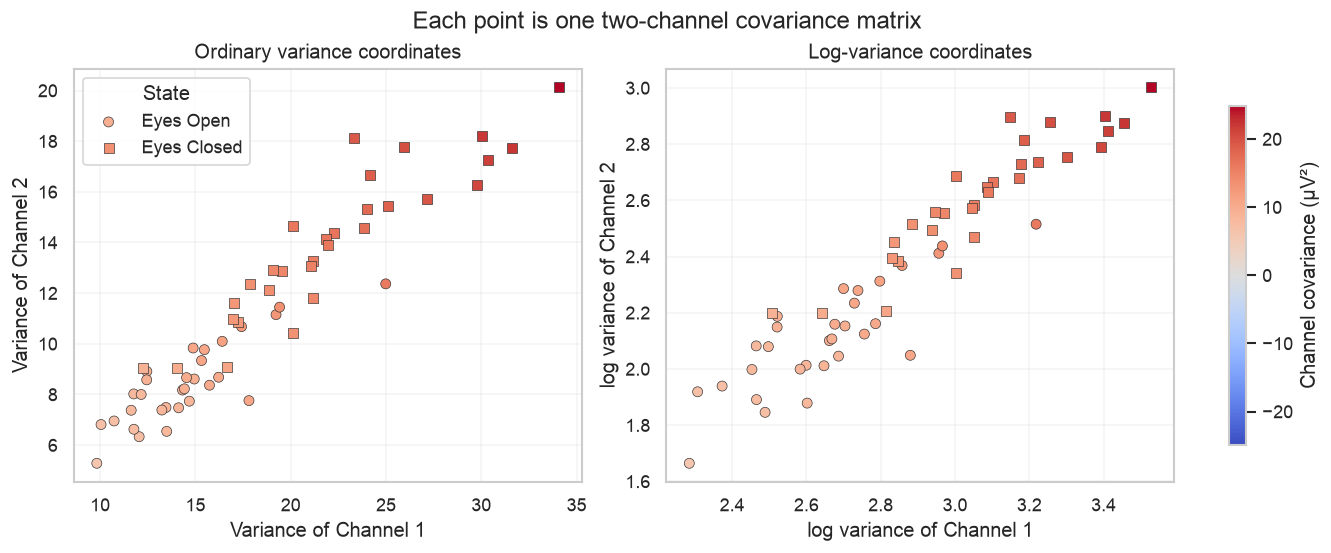

In [26]:
channel_pair = list(CHANNEL_PAIR)
covariances_by_state = {}
for state_code in STATE_ORDER:
    mask = (window_subjects == subject_order[0]) & (window_states == state_code)
    pair_covariances = window_covariances[mask][:, channel_pair][:, :, channel_pair]
    covariances_by_state[STATE_NAMES[state_code]] = pair_covariances * 1e12

space_figure = plot_covariance_space(
    covariances_by_state,
    channel_names=("Channel 1", "Channel 2"),
)
space_figure.axes[-1].set_ylabel("Channel covariance (µV²)")
space_figure;

The ellipse and heatmap show the same covariance structure at two scales. The covariance-space plot then shows how that structure varies across windows and recording states.

## 5. Tangent-space features

Tangent-space projection turns each covariance matrix into an ordinary feature vector relative to a shared reference. PCA is used here only to visualize those features in two dimensions.

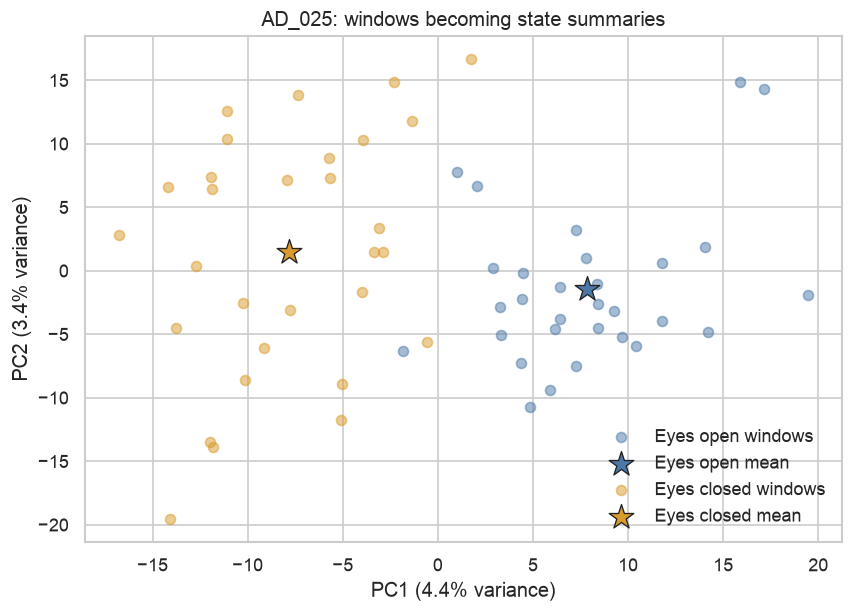

In [27]:
example_subject_mask = window_subjects == subject_order[0]
example_window_covariances = window_covariances[example_subject_mask]
example_window_states = window_states[example_subject_mask]

window_tangent_features = TangentSpace().fit_transform(example_window_covariances)
scaled_window_features = StandardScaler().fit_transform(window_tangent_features)
window_pca = PCA(n_components=2)
window_embedding = window_pca.fit_transform(scaled_window_features)

figure, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
for state_code in STATE_ORDER:
    mask = example_window_states == state_code
    points = window_embedding[mask]
    axis.scatter(
        points[:, 0],
        points[:, 1],
        color=STATE_COLORS[state_code],
        alpha=0.5,
        label=f"{STATE_NAMES[state_code]} windows",
    )
    axis.scatter(
        points[:, 0].mean(),
        points[:, 1].mean(),
        color=STATE_COLORS[state_code],
        marker="*",
        edgecolor="#222222",
        linewidth=0.8,
        s=240,
        label=f"{STATE_NAMES[state_code]} mean",
    )

axis.set(
    title=f"{aligned_subject_ids[0]}: windows becoming state summaries",
    xlabel=f"PC1 ({window_pca.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2 ({window_pca.explained_variance_ratio_[1]:.1%} variance)",
)
axis.legend(frameon=False)
figure;

del windows

The lines in the first plot connect each subject’s eyes-open and eyes-closed points.

The second plot takes a closer look at one subject. Each dot is a 2-second EEG window, summarized by its covariance matrix. We map those matrices into a regular feature space and use PCA to make a 2D plot. The colors show whether the subject’s eyes were open or closed, and each star marks the average position for that state. If the two groups separate, their EEG covariance patterns differ; if they overlap, the patterns look similar in this view. PC1 and PC2 are summaries of the data rather than individual EEG channels, and the percentages show how much variation they capture.

This plot is only an illustration. In a predictive analysis, transformations must be fitted on the training data, and all windows from the same subject must stay in the same cross-validation fold.

## 6. Minimum Distance to Mean classification

MDM predicts the class with the closest mean covariance matrix. This small example uses eyes-closed data only and plots out-of-fold distances, so each subject was excluded when its class means were fitted.

Correct predictions in this subset: 8/10


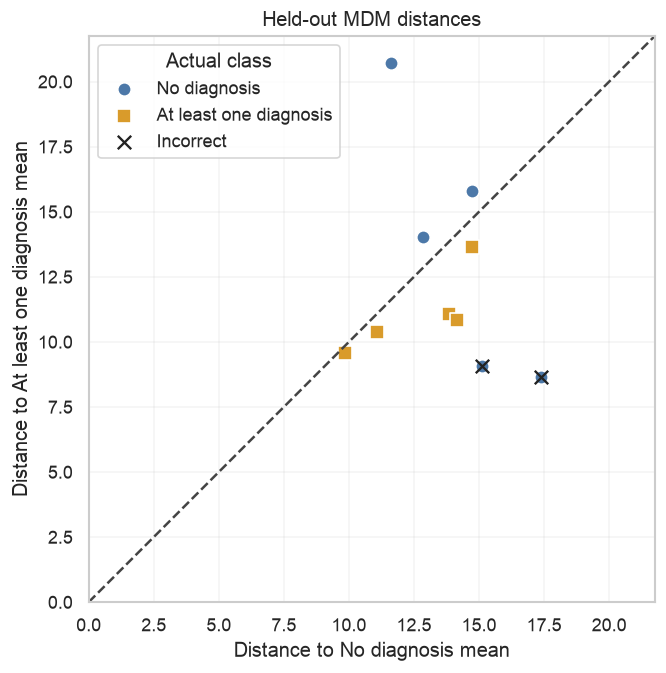

In [28]:
eyes_closed_covariances = subject_state_covariances[:, 1]
classes = np.unique(aligned_target)
folds = make_subject_folds(
    aligned_target,
    aligned_subject_ids,
    n_splits=2,
    random_state=RANDOM_STATE,
)

held_out_distances = np.full((n_subjects, len(classes)), np.nan)
for train_index, test_index in folds:
    mdm = MDM(metric="riemann").fit(
        eyes_closed_covariances[train_index],
        aligned_target[train_index],
    )
    held_out_distances[test_index] = mdm.transform(
        eyes_closed_covariances[test_index]
    )

mdm_predictions = classes[np.argmin(held_out_distances, axis=1)]
mdm_figure = plot_mdm_distances(
    held_out_distances,
    aligned_target,
    classes=classes,
    class_names=("No diagnosis", "At least one diagnosis"),
)
mdm_figure;

print(
    "Correct predictions in this subset:",
    f"{np.count_nonzero(mdm_predictions == aligned_target)}/{n_subjects}",
)

Below the diagonal, the diagnosis mean is closer; above it, the no-diagnosis mean is closer. A black cross marks an incorrect prediction.

This balanced ten-subject example is a geometry check, not a performance estimate. `StateAwareMDM` extends the same idea by fitting class means within each recording state.

**samples → state-specific windows → covariance matrices → tangent features or Riemannian distances → subject prediction**